In [4]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Setup erfolgreich.")
print("TensorFlow-Version:", tf.__version__)

Setup erfolgreich.
TensorFlow-Version: 2.21.0


In [5]:
dataset = fetch_ucirepo(id=697)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

df = X.copy()
df["Target"] = y

print("Datensatz erfolgreich geladen.")
print("Shape:", df.shape)

df.head()

Datensatz erfolgreich geladen.
Shape: (4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
print("Shape des Datensatzes:")
display(df.shape)

print("\nErste fünf Zeilen:")
display(df.head())

print("\nDatentypen und Non-Null-Werte:")
df.info()

print("\nDeskriptive Statistik:")
display(df.describe().T)

Shape des Datensatzes:


(4424, 37)


Erste fünf Zeilen:


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Datentypen und Non-Null-Werte:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualificati

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Fehlende Werte pro Spalte:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Es gibt keine fehlenden Werte im Datensatz.")
else:
    print("Es gibt fehlende Werte. Diese werden später im Preprocessing behandelt.")

Fehlende Werte pro Spalte:


Series([], dtype: int64)

Es gibt keine fehlenden Werte im Datensatz.


,Anzahl,Prozent
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


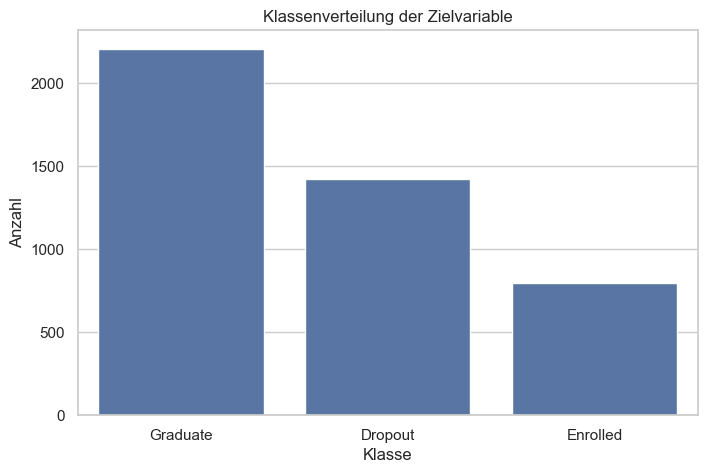

In [8]:
target_counts = df["Target"].value_counts()
target_percentages = df["Target"].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "Anzahl": target_counts,
    "Prozent": target_percentages.round(2)
})

display(target_distribution)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Target", order=target_counts.index)
plt.title("Klassenverteilung der Zielvariable")
plt.xlabel("Klasse")
plt.ylabel("Anzahl")
plt.show()

In [9]:
dtype_summary = df.dtypes.value_counts()

print("Datentypen im Datensatz:")
display(dtype_summary)

print("\nSpalten und Datentypen:")
display(df.dtypes)

Datentypen im Datensatz:


int64      29
float64     7
str         1
Name: count, dtype: int64


Spalten und Datentypen:


Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [10]:
target_column = "Target"

categorical_columns = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

categorical_columns = [col for col in categorical_columns if col in df.columns]

numeric_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

print("Kategorische Features:", len(categorical_columns))
display(categorical_columns)

print("Numerische Features:", len(numeric_columns))
display(numeric_columns)

Kategorische Features: 17


['Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'International']

Numerische Features: 19


['Marital Status',
 'Previous qualification (grade)',
 'Admission grade',
 'Age at enrollment',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rate',
 'GDP']

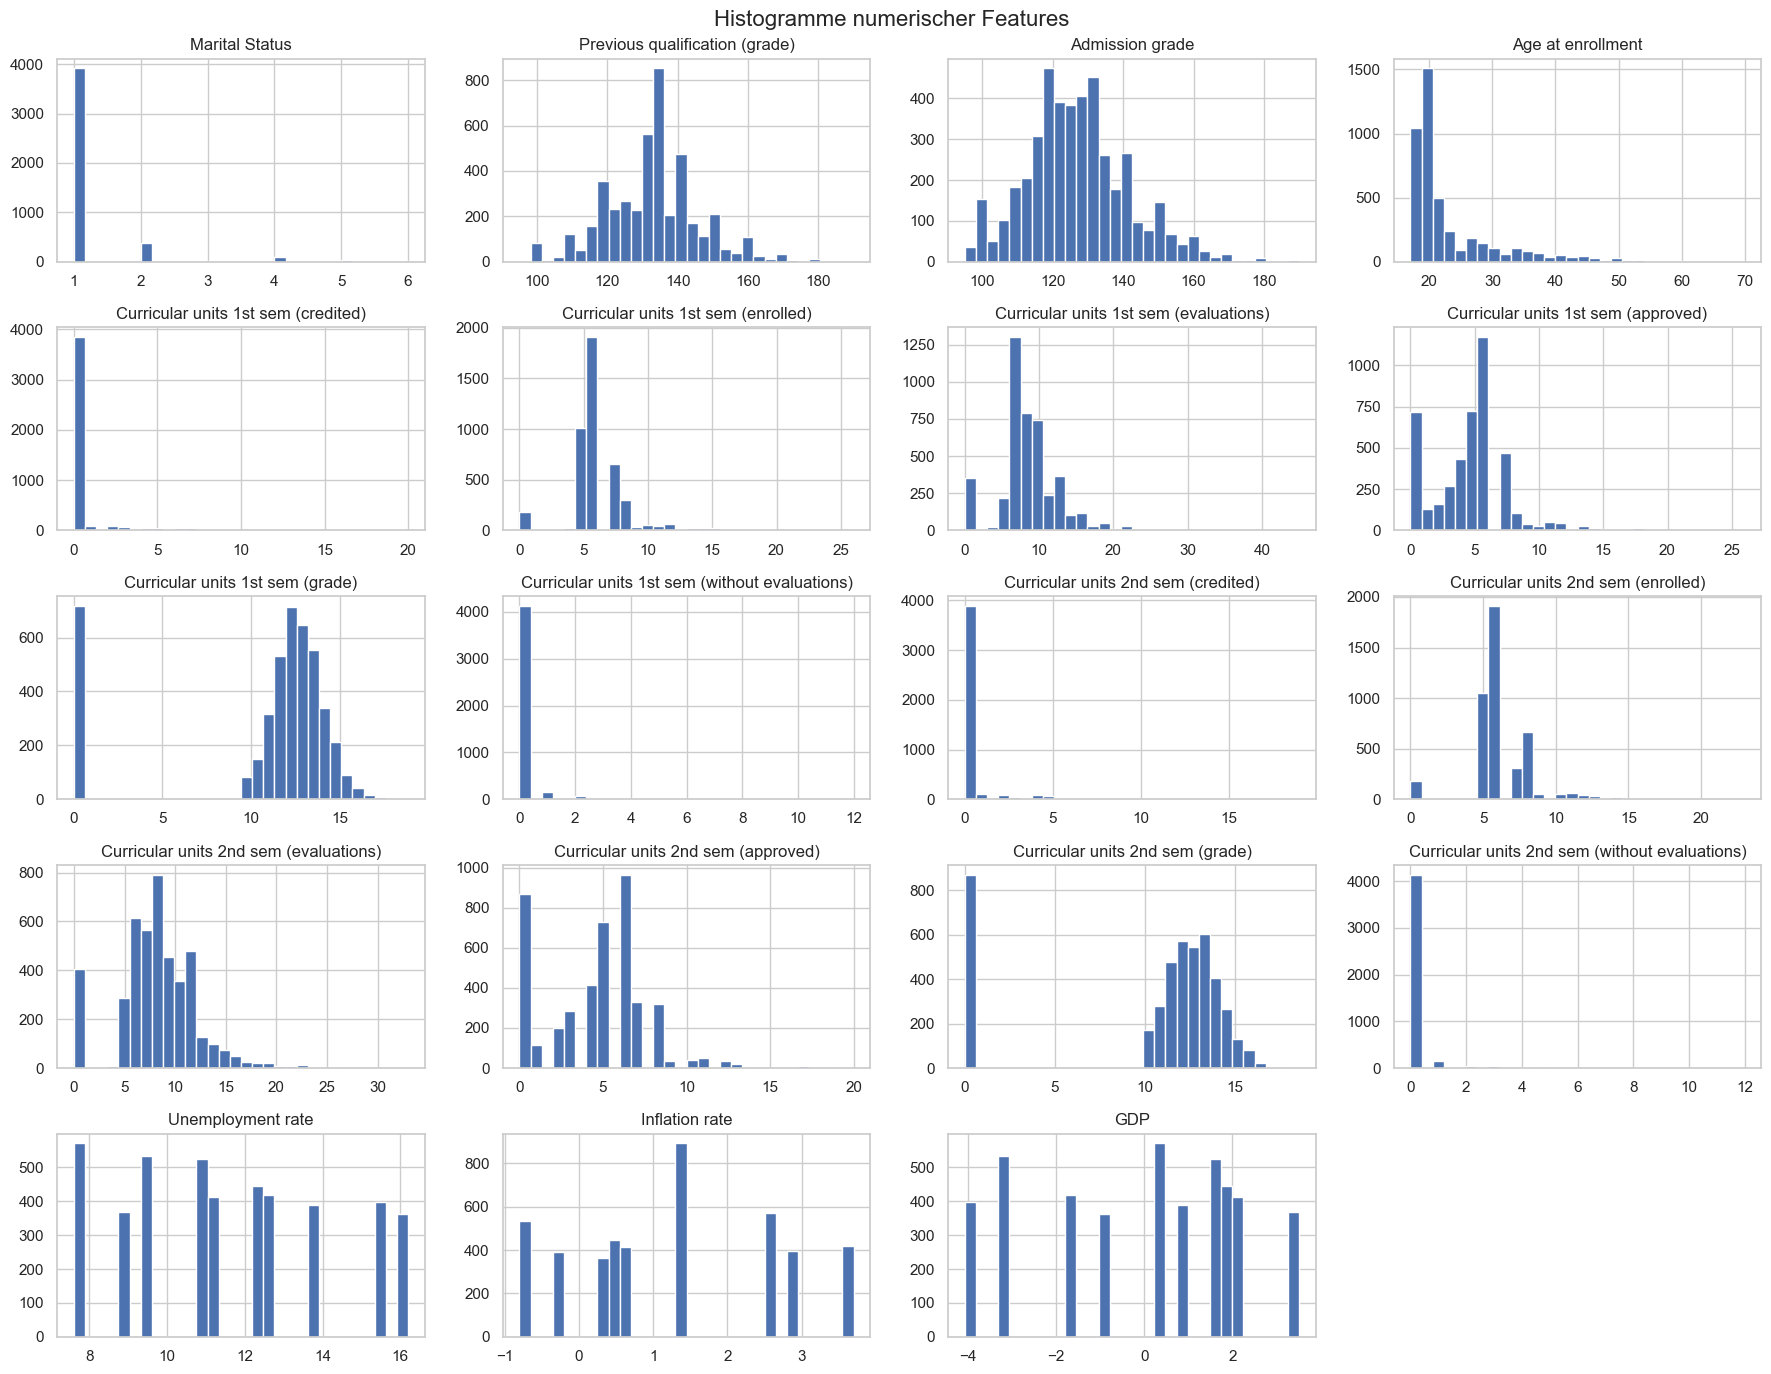

In [11]:
df[numeric_columns].hist(figsize=(18, 14), bins=30)
plt.suptitle("Histogramme numerischer Features", fontsize=16)
plt.tight_layout()
plt.show()

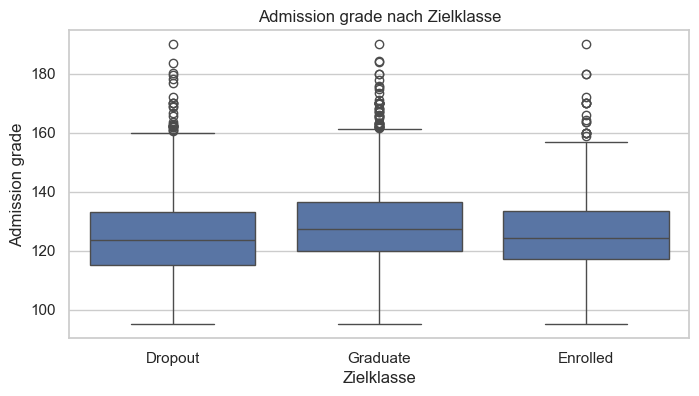

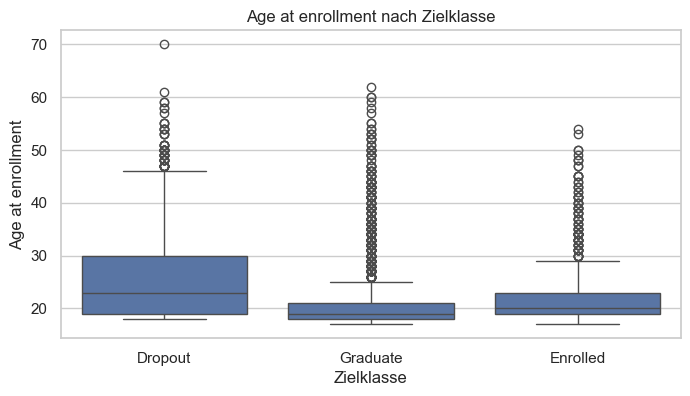

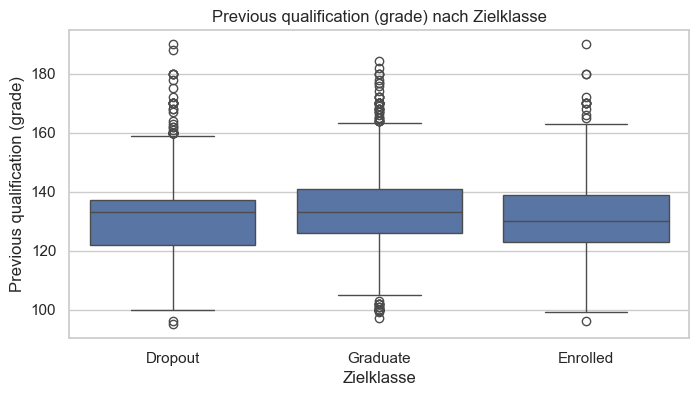

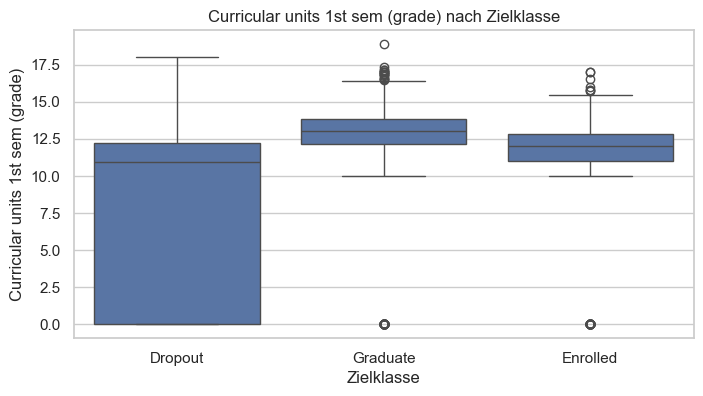

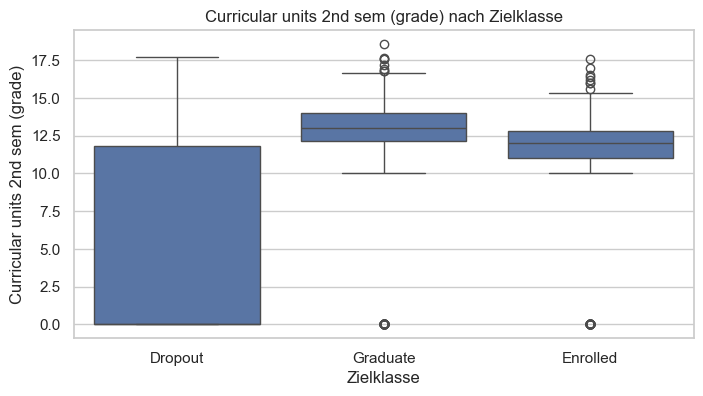

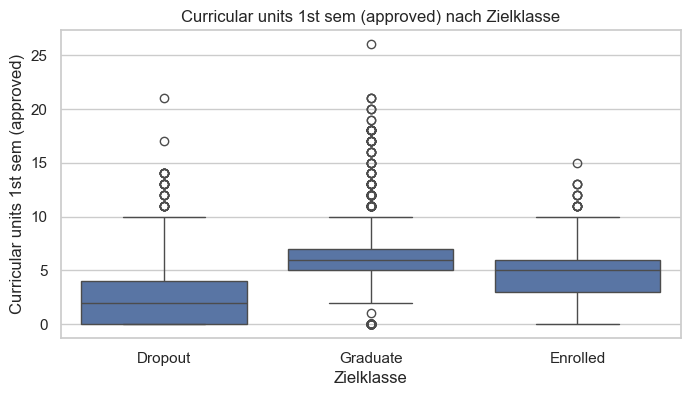

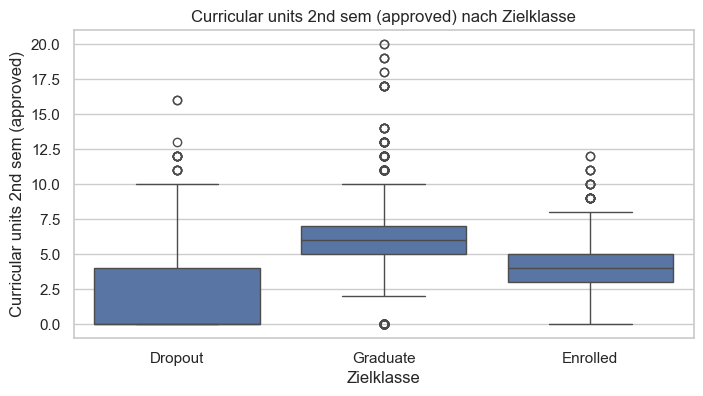

In [12]:
important_numeric_features = [
    "Admission grade",
    "Age at enrollment",
    "Previous qualification (grade)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]

important_numeric_features = [
    col for col in important_numeric_features
    if col in df.columns
]

for col in important_numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Target", y=col)
    plt.title(f"{col} nach Zielklasse")
    plt.xlabel("Zielklasse")
    plt.ylabel(col)
    plt.show()

In [ ]:
Die Boxplots zeigen Unterschiede zwischen den Klassen.
Besonders akademische Leistungsmerkmale wie bestandene oder bewertete Curricular Units unterscheiden sich häufig deutlich zwischen Dropout und Graduate.
Das ist fachlich plausibel, weil Studienleistung ein starker Indikator für Studienerfolg ist.

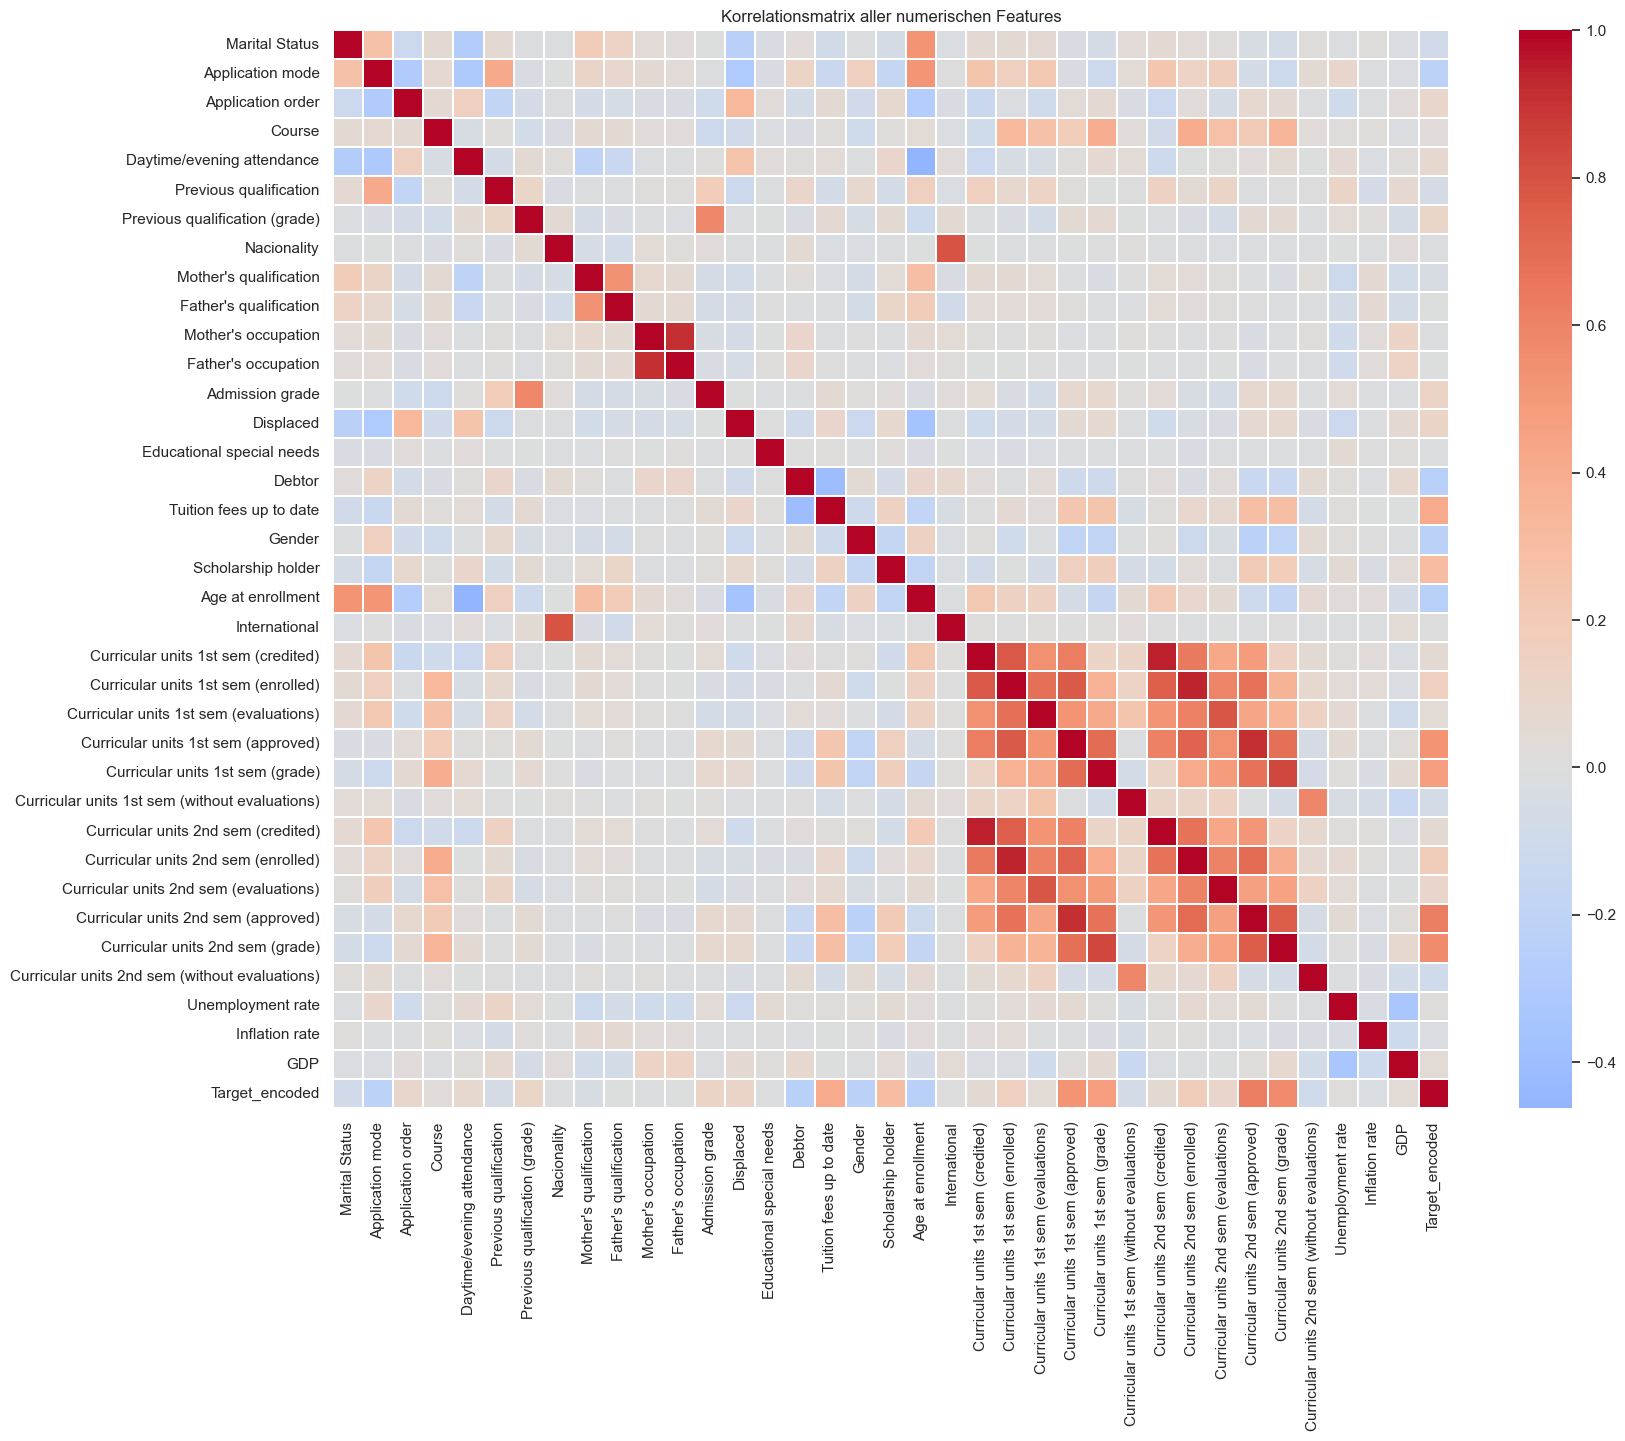

In [13]:
df_encoded_for_corr = df.copy()

label_encoder_corr = LabelEncoder()
df_encoded_for_corr["Target_encoded"] = label_encoder_corr.fit_transform(df_encoded_for_corr["Target"])

correlation_matrix = df_encoded_for_corr.drop(columns=["Target"]).corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title("Korrelationsmatrix aller numerischen Features")
plt.show()

In [ ]:
Die Korrelationsmatrix zeigt lineare Zusammenhänge zwischen Features.
Starke positive oder negative Korrelationen können auf redundante Informationen hinweisen.
Bei Bildungsdaten sind hohe Zusammenhänge zwischen Features der ersten und zweiten Studiensemester erwartbar.

In [ ]:
Zelle 12: Korrelation mit Zielvariable

Target_encoded                         1.000000
Curricular units 2nd sem (approved)    0.624157
Curricular units 2nd sem (grade)       0.566827
Curricular units 1st sem (approved)    0.529123
Curricular units 1st sem (grade)       0.485207
Tuition fees up to date                0.409827
Scholarship holder                     0.297595
Age at enrollment                     -0.243438
Debtor                                -0.240999
Gender                                -0.229270
Application mode                      -0.221747
Curricular units 2nd sem (enrolled)    0.175847
Curricular units 1st sem (enrolled)    0.155974
Admission grade                        0.120889
Displaced                              0.113986
Name: Target_encoded, dtype: float64

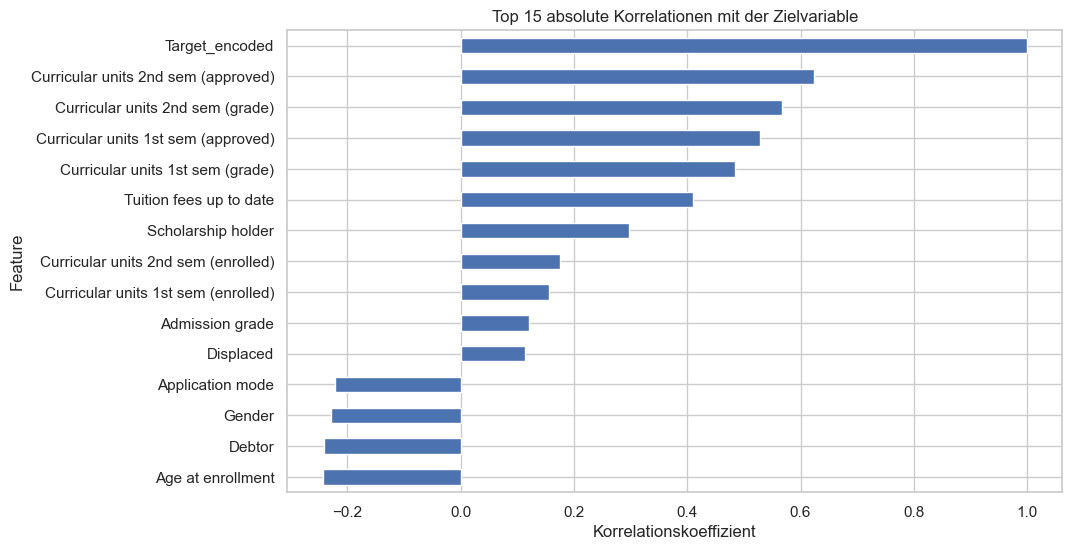

In [14]:
target_correlations = (
    df_encoded_for_corr
    .drop(columns=["Target"])
    .corr(numeric_only=True)["Target_encoded"]
    .sort_values(key=abs, ascending=False)
)

display(target_correlations.head(15))

plt.figure(figsize=(10, 6))
target_correlations.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 absolute Korrelationen mit der Zielvariable")
plt.xlabel("Korrelationskoeffizient")
plt.ylabel("Feature")
plt.show()

In [ ]:
Korrelation bedeutet nicht automatisch Kausalität.
Ein Feature kann stark mit der Zielvariable zusammenhängen, ohne direkt die Ursache für Studienabbruch oder Studienerfolg zu sein.

In [ ]:
Zelle 13: Train/Test Split

In [15]:
X = df.drop(columns=["Target"])
y = df["Target"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klassen-Mapping:")
for index, class_name in enumerate(label_encoder.classes_):
    print(index, "=", class_name)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

print("\nKlassenverteilung im Trainingsset:")
display(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nKlassenverteilung im Testset:")
display(pd.Series(y_test).value_counts(normalize=True).sort_index())

Klassen-Mapping:
0 = Dropout
1 = Enrolled
2 = Graduate
Trainingsdaten: (3539, 36)
Testdaten: (885, 36)

Klassenverteilung im Trainingsset:


0    0.321277
1    0.179429
2    0.499294
Name: proportion, dtype: float64


Klassenverteilung im Testset:


0    0.320904
1    0.179661
2    0.499435
Name: proportion, dtype: float64

In [ ]:
Der Split ist stratified. Dadurch bleibt die Klassenverteilung in Training und Test ähnlich.
Das ist bei unbalancierten Klassifikationsproblemen wichtig.

In [ ]:
Zelle 14: Preprocessing Pipeline

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_columns),
        ("categorical", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing-Pipeline erstellt.")

Preprocessing-Pipeline erstellt.


In [ ]:
Numerische Features werden mit dem Median imputiert und anschließend standardisiert.
Kategorische Features werden mit dem häufigsten Wert imputiert und danach per One-Hot-Encoding umgewandelt.
Das gesamte Preprocessing wird nur auf den Trainingsdaten gelernt, um Data Leakage zu vermeiden.

In [19]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Berechnet zentrale Klassifikationsmetriken für ein Modell.
    """
    results = {
        "Modell": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }
    return results


def plot_confusion_matrix(y_true, y_pred, title):
    """
    Visualisiert die Confusion Matrix.
    """
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

start_time = time.time()

rf_pipeline.fit(X_train, y_train)

rf_training_time = time.time() - start_time

rf_predictions = rf_pipeline.predict(X_test)

print("Random Forest Training abgeschlossen.")
print("Trainingszeit:", round(rf_training_time, 2), "Sekunden")

Random Forest Training abgeschlossen.
Trainingszeit: 1.58 Sekunden


In [ ]:
Random Forest ist für tabellarische Daten sehr geeignet.
Das Modell kann nichtlineare Zusammenhänge erkennen, ist robust gegenüber Ausreißern und liefert Feature Importances.
Außerdem ist es einfacher interpretierbar als ein neuronales Netz.

In [ ]:
Zelle 17: Random Forest Evaluation

,Modell,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,Random Forest,0.766102,0.715759,0.704705,0.709054,0.764348,0.766102,0.763899


Classification Report - Random Forest:
              precision    recall  f1-score   support

     Dropout       0.81      0.72      0.76       284
    Enrolled       0.51      0.50      0.51       159
    Graduate       0.83      0.89      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885



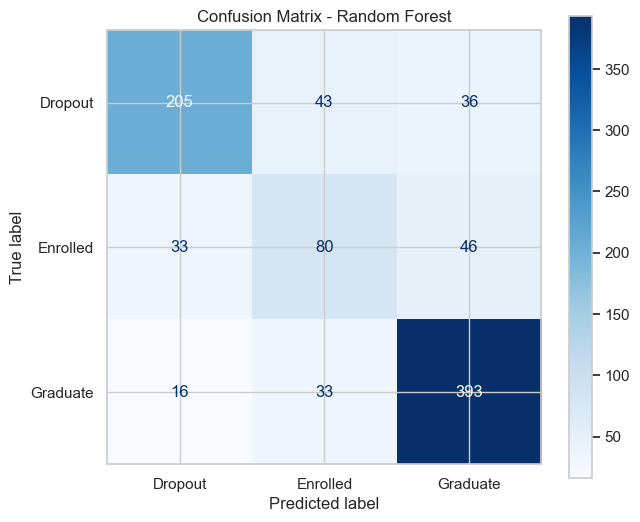

In [21]:
rf_results = evaluate_model(
    model_name="Random Forest",
    y_true=y_test,
    y_pred=rf_predictions
)

display(pd.DataFrame([rf_results]))

print("Classification Report - Random Forest:")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=rf_predictions,
    title="Confusion Matrix - Random Forest"
)

In [ ]:
Accuracy misst den Anteil korrekt klassifizierter Fälle.
Precision zeigt, wie zuverlässig positive Vorhersagen einer Klasse sind.
Recall zeigt, wie viele echte Fälle einer Klasse gefunden wurden.
F1-Score kombiniert Precision und Recall.
Macro-Metriken behandeln alle Klassen gleich.
Weighted-Metriken berücksichtigen die Klassenhäufigkeiten.

In [ ]:
Zelle 18: Feature Importance Random Forest

,Feature,Importance
13,numeric__Curricular units 2nd sem (approved),0.110620
14,numeric__Curricular units 2nd sem (grade),0.090229
7,numeric__Curricular units 1st sem (approved),0.077134
8,numeric__Curricular units 1st sem (grade),0.058621
12,numeric__Curricular units 2nd sem (evaluations),0.043914
6,numeric__Curricular units 1st sem (evaluations),0.041357
2,numeric__Admission grade,0.034908
3,numeric__Age at enrollment,0.033246
1,numeric__Previous qualification (grade),0.029442
238,categorical__Tuition fees up to date_0,0.028652


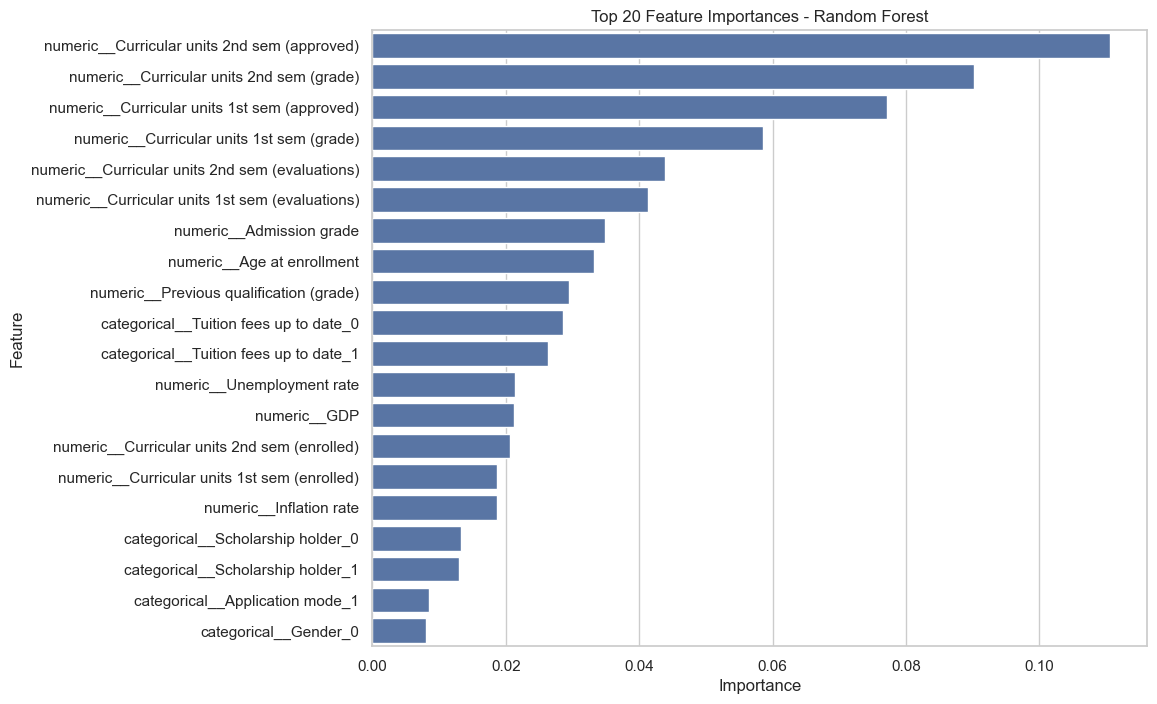

In [22]:
preprocessor_fitted = rf_pipeline.named_steps["preprocessor"]
rf_fitted = rf_pipeline.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
feature_importances = rf_fitted.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
Die Feature Importance zeigt, welche Variablen für die Modellentscheidung besonders relevant waren.
Bei diesem Datensatz sind häufig akademische Leistungsvariablen aus dem ersten und zweiten Semester besonders wichtig.
Das ist plausibel, weil Studienerfolg stark mit bisherigen Studienleistungen zusammenhängt.

In [ ]:
Zelle 19: Preprocessing für Deep Learning

In [23]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Train DL:", X_train_dl.shape)
print("Validation DL:", X_val_dl.shape)
print("Test DL:", X_test_processed.shape)

Train DL: (2831, 246)
Validation DL: (708, 246)
Test DL: (885, 246)


In [ ]:
Das Deep-Learning-Modell bekommt exakt dieselben Trainings- und Testdaten wie der Random Forest.
Zusätzlich wird innerhalb der Trainingsdaten ein Validierungsset erzeugt, damit Early Stopping möglich ist.

In [ ]:
Zelle 20: Class Weights für Deep Learning

In [24]:
classes = np.unique(y_train_dl)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_dl
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, class_weights_array)
}

print("Class Weights:")
display(class_weights)

Class Weights:


{0: 1.036996336996337, 1: 1.8576115485564304, 2: 0.6678461901391838}

In [ ]:
Class Weights geben selteneren Klassen ein höheres Gewicht im Training.
Das ist sinnvoll, wenn die Zielklassen nicht gleich häufig vorkommen.

In [ ]:
Zelle 21: Eigenes Deep-Learning-Modell bauen

In [25]:
input_dim = X_train_dl.shape[1]
num_classes = len(label_encoder.classes_)

dl_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.0001)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.0001)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(
        32,
        activation="relu"
    ),
    layers.Dropout(0.15),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

dl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          31,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,819 (167.26 KB)

 Trainable params: 42,435 (165.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
Das Modell ist ein vollständig selbst gebautes neuronales Netz für tabellarische Daten.
Dense Layers lernen nichtlineare Zusammenhänge.
ReLU wird verwendet, weil sie effizient ist und Vanishing Gradients reduziert.
Dropout und L2-Regularisierung reduzieren Overfitting.
Softmax erzeugt Wahrscheinlichkeiten für die drei Zielklassen.
Sparse Categorical Crossentropy ist passend, weil die Klassen als Integer codiert sind.

In [ ]:
Zelle 22: Deep Learning Training

In [26]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-5
)

start_time = time.time()

history = dl_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=150,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

dl_training_time = time.time() - start_time

print("Deep Learning Training abgeschlossen.")
print("Trainingszeit:", round(dl_training_time, 2), "Sekunden")

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5397 - loss: 1.1447 - val_accuracy: 0.6130 - val_loss: 0.9644 - learning_rate: 0.0010
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6280 - loss: 0.9120 - val_accuracy: 0.6893 - val_loss: 0.8450 - learning_rate: 0.0010
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6757 - loss: 0.8209 - val_accuracy: 0.6864 - val_loss: 0.7782 - learning_rate: 0.0010
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6934 - loss: 0.7745 - val_accuracy: 0.7161 - val_loss: 0.7215 - learning_rate: 0.0010
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7160 - loss: 0.7135 - val_accuracy: 0.7189 - val_loss: 0.6969 - learning_rate: 0.0010
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7323 - loss: 0.6826 - val_accuracy: 0.7274 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7446 - loss: 0.6545 - val_ac

In [ ]:
Zelle 23: Trainingskurven visualisieren

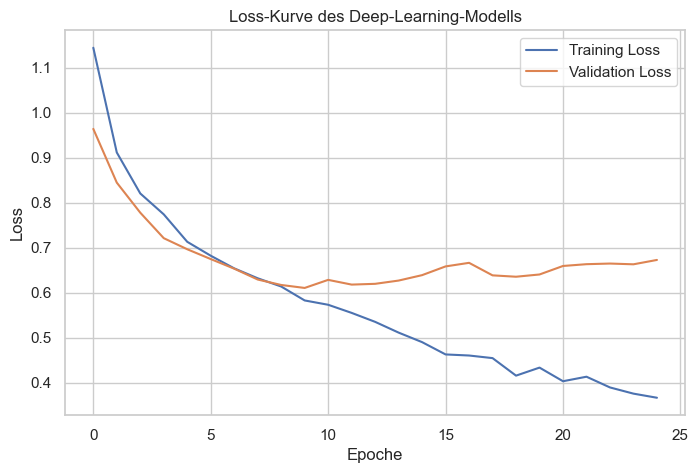

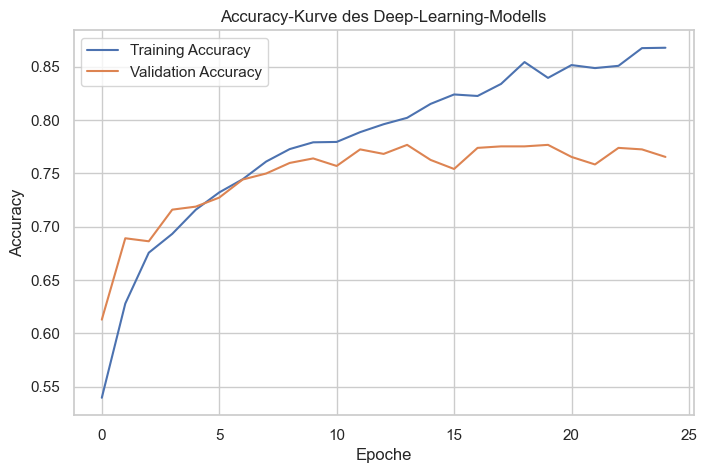

In [27]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Loss-Kurve des Deep-Learning-Modells")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy-Kurve des Deep-Learning-Modells")
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
Wenn Training Loss stark sinkt, aber Validation Loss steigt, deutet das auf Overfitting hin.
Wenn beide Kurven ähnlich verlaufen, generalisiert das Modell besser.
Early Stopping verhindert, dass zu lange trainiert wird.

In [ ]:
Zelle 24: Deep Learning Evaluation auf Testset

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,Modell,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,Deep Learning MLP,0.716384,0.690913,0.688384,0.679035,0.759964,0.716384,0.730925


Classification Report - Deep Learning MLP:
              precision    recall  f1-score   support

     Dropout       0.84      0.68      0.75       284
    Enrolled       0.39      0.60      0.48       159
    Graduate       0.84      0.78      0.81       442

    accuracy                           0.72       885
   macro avg       0.69      0.69      0.68       885
weighted avg       0.76      0.72      0.73       885



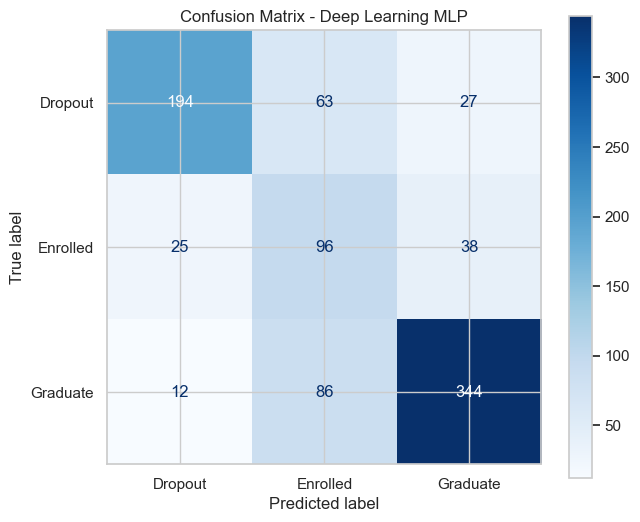

In [28]:
dl_probabilities = dl_model.predict(X_test_processed)
dl_predictions = np.argmax(dl_probabilities, axis=1)

dl_results = evaluate_model(
    model_name="Deep Learning MLP",
    y_true=y_test,
    y_pred=dl_predictions
)

display(pd.DataFrame([dl_results]))

print("Classification Report - Deep Learning MLP:")
print(
    classification_report(
        y_test,
        dl_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=dl_predictions,
    title="Confusion Matrix - Deep Learning MLP"
)

In [ ]:
Das Deep-Learning-Modell wird auf demselben Testset evaluiert wie der Random Forest.
Dadurch ist der Vergleich fair.

In [ ]:
Zelle 25: Modellvergleich

,Modell,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted,Trainingszeit_Sekunden
0,Random Forest,0.766102,0.715759,0.704705,0.709054,0.764348,0.766102,0.763899,1.584547
1,Deep Learning MLP,0.716384,0.690913,0.688384,0.679035,0.759964,0.716384,0.730925,10.560030


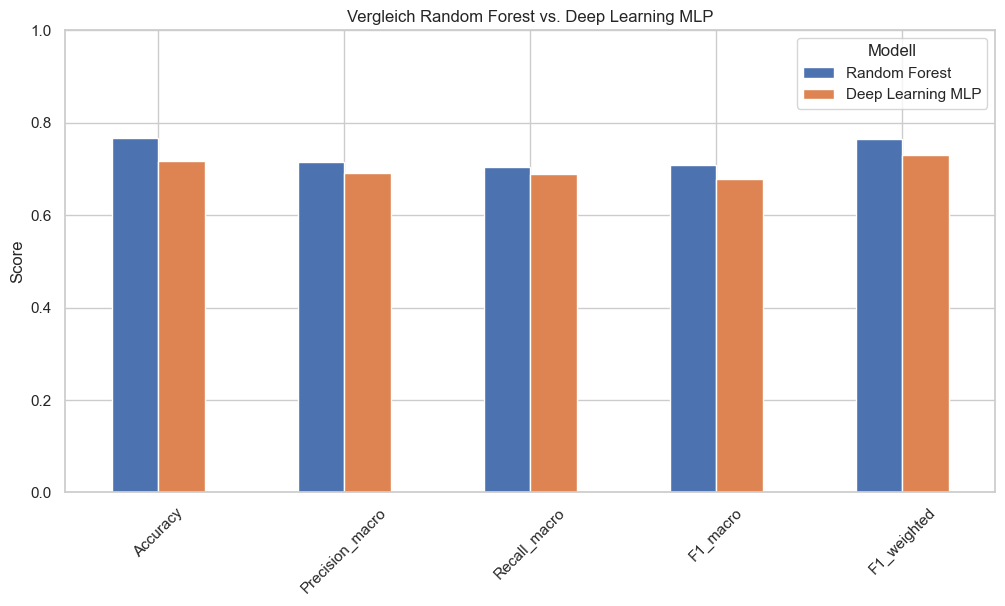

In [29]:
comparison_df = pd.DataFrame([
    rf_results,
    dl_results
])

comparison_df["Trainingszeit_Sekunden"] = [
    rf_training_time,
    dl_training_time
]

display(comparison_df)

metrics_to_plot = [
    "Accuracy",
    "Precision_macro",
    "Recall_macro",
    "F1_macro",
    "F1_weighted"
]

comparison_plot_df = comparison_df.set_index("Modell")[metrics_to_plot]

comparison_plot_df.T.plot(kind="bar", figsize=(12, 6))
plt.title("Vergleich Random Forest vs. Deep Learning MLP")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title="Modell")
plt.show()

In [ ]:
Das bessere Modell ist nicht nur anhand der Accuracy zu beurteilen.
Bei unbalancierten Klassen sind besonders Macro-F1 und klassenspezifischer Recall wichtig.
Random Forest ist häufig stärker bei tabellarischen Daten und besser interpretierbar.
Das neuronale Netz kann nichtlineare Muster lernen, benötigt aber mehr Tuning und ist weniger transparent.

In [ ]:
Zelle 26: Automatische Entscheidungshilfe

In [30]:
best_model_by_f1 = comparison_df.sort_values(
    by="F1_macro",
    ascending=False
).iloc[0]

print("Bestes Modell nach Macro-F1:")
print(best_model_by_f1["Modell"])
print("Macro-F1:", round(best_model_by_f1["F1_macro"], 4))

Bestes Modell nach Macro-F1:
Random Forest
Macro-F1: 0.7091


In [ ]:
Ich verwende Macro-F1 als wichtige Vergleichsmetrik, weil alle Klassen gleich stark berücksichtigt werden.
Das ist bei einem unbalancierten Mehrklassenproblem aussagekräftiger als reine Accuracy.